# Principal Component Analysis (PCA)

**Objectif**: Réduire la dimensionnalité du dataset Wine via PCA, puis sélectionner le nombre optimal de composantes avec validation explicite.

- Dataset: Wine (178 samples, 13 features)
- Approche: Split train/val/test → sélection n_components via validation → évaluation test
- Modèle de classification: Logistic Regression

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

In [2]:
# 1) Chargement des données et split train/val/test
X, y = load_wine(return_X_y=True)
print(f"Shape X: {X.shape}")

# Split stratifié: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split du train_full: 75% train (60% global), 25% val (20% global)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Shape X: (178, 13)
Train: (106, 13), Val: (36, 13), Test: (36, 13)


In [3]:
# 2) Standardisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Standardisation complète")

Standardisation complète


In [4]:
# 3) Sélection du nombre optimal de composantes via validation
n_max = X_train.shape[1]
val_scores = []

for n in range(1, n_max + 1):
    pca = PCA(n_components=n, random_state=42)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    
    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(X_train_p, y_train)
    pred_val = clf.predict(X_val_p)
    val_scores.append(accuracy_score(y_val, pred_val))

best_n = int(np.argmax(val_scores) + 1)
best_val = float(np.max(val_scores))

print(f"Meilleur n_components (via validation): {best_n}")
print(f"Accuracy validation max: {best_val:.4f}")

Meilleur n_components (via validation): 2
Accuracy validation max: 1.0000


In [9]:
# 4) Refit sur train+val avec le meilleur n_components, puis évaluation test
X_trainval_s = scaler.fit_transform(X_train_full)
X_test_s = scaler.transform(X_test)

best_pca = PCA(n_components=best_n, random_state=42)
X_trainval_p = best_pca.fit_transform(X_trainval_s)
X_test_p = best_pca.transform(X_test_s)

final_clf = LogisticRegression(max_iter=2000, random_state=42)
final_clf.fit(X_trainval_p, y_train_full)
test_pred = final_clf.predict(X_test_p)

# Métriques globales
acc = accuracy_score(y_test, test_pred)
bacc = balanced_accuracy_score(y_test, test_pred)

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, test_pred, average="macro", zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, test_pred, average="weighted", zero_division=0
)

# Détails par classe
cm = confusion_matrix(y_test, test_pred)
report = classification_report(y_test, test_pred, zero_division=0)

print(f"Accuracy test: {acc:.4f}")
print(f"Balanced accuracy test: {bacc:.4f}")
print(f"Precision macro: {p_macro:.4f} | Recall macro: {r_macro:.4f} | F1 macro: {f1_macro:.4f}")
print(
    f"Precision weighted: {p_weighted:.4f} | Recall weighted: {r_weighted:.4f} | "
    f"F1 weighted: {f1_weighted:.4f}"
)
print(f"Variance expliquée cumulative (best_n={best_n}): {best_pca.explained_variance_ratio_.sum():.4f}")
print("\nMatrice de confusion:\n", cm)
print("\nClassification report:\n", report)

Accuracy test: 0.9167
Balanced accuracy test: 0.9151
Precision macro: 0.9278 | Recall macro: 0.9151 | F1 macro: 0.9202
Precision weighted: 0.9204 | Recall weighted: 0.9167 | F1 weighted: 0.9174
Variance expliquée cumulative (best_n=2): 0.5506

Matrice de confusion:
 [[11  1  0]
 [ 1 13  0]
 [ 0  1  9]]

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.87      0.93      0.90        14
           2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



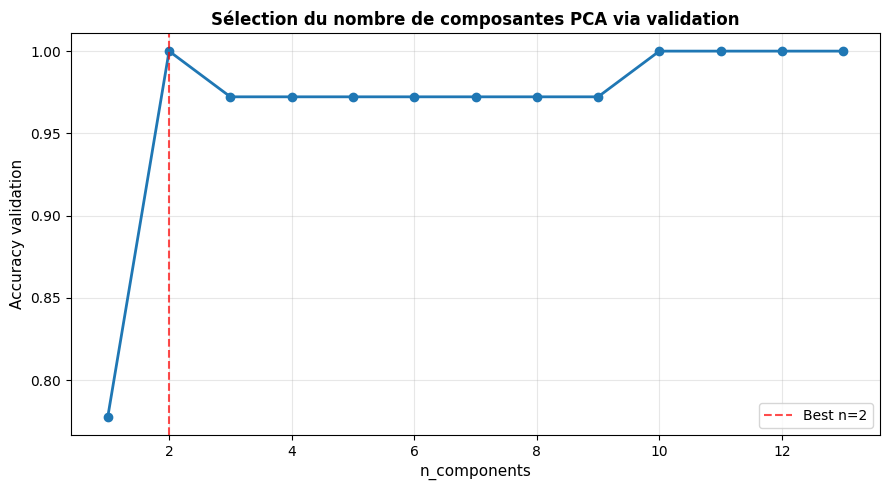

In [6]:
# 5) Visualisation: sélection du nombre de composantes
plt.figure(figsize=(9, 5))
plt.plot(range(1, n_max + 1), val_scores, marker="o", linewidth=2, markersize=6)
plt.axvline(best_n, color="red", linestyle="--", alpha=0.7, label=f"Best n={best_n}")
plt.title("Sélection du nombre de composantes PCA via validation", fontsize=12, fontweight="bold")
plt.xlabel("n_components", fontsize=11)
plt.ylabel("Accuracy validation", fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

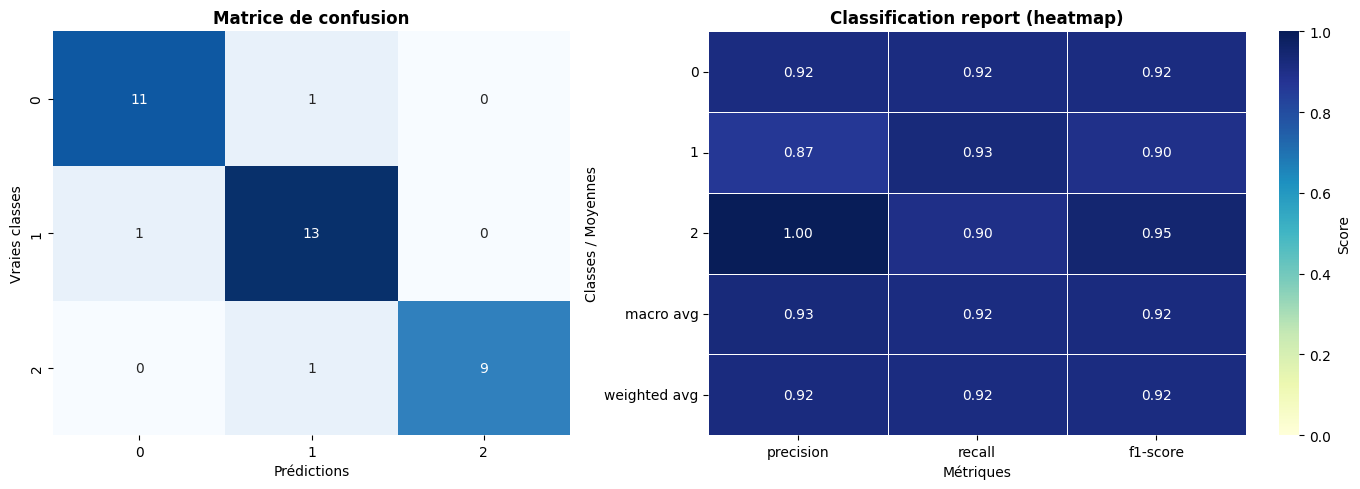

In [10]:
# 6) Belle visualisation: matrice de confusion + classification report
class_names = [str(c) for c in np.unique(y_test)]

# DataFrame du classification report pour la heatmap
report_dict = classification_report(y_test, test_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T

# On garde les classes + macro/weighted avg pour la visualisation
rows_to_show = class_names + ["macro avg", "weighted avg"]
metrics_to_show = ["precision", "recall", "f1-score"]
heatmap_df = report_df.loc[rows_to_show, metrics_to_show]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.3]})

# Matrice de confusion
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title("Matrice de confusion", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Vraies classes")

# Classification report (precision / recall / f1)
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Score"},
    ax=axes[1],
)
axes[1].set_title("Classification report (heatmap)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Métriques")
axes[1].set_ylabel("Classes / Moyennes")

plt.tight_layout()
plt.show()